<b>¡Hola Aron!</b>

Mi nombre es Alejandro Abia y tengo el gusto de revisar tu proyecto.

A continuación, encontrarás mis comentarios en celdas pintadas de tres colores (verde, amarillo y rojo), a manera de semáforo. Por favor, <b>no las borres ni muevas de posición</b> mientras dure el proceso de revisión.

<div class="alert alert-block alert-success">
<b>Éxito</b> <a class="tocSkip"></a>
En celdas verdes encontrarás comentarios en relación a tus aciertos y fortalezas.
</div>
<div class="alert alert-block alert-warning">
<b>Antención</b> <a class="tocSkip"></a>
Utilizaré el color amarillo para llamar tu atención, expresar algo importante o compartirte alguna idea de valor.
</div>
<div class="alert alert-block alert-danger">
<b>A resolver</b> <a class="tocSkip"></a>
En rojo emitiré aquellos puntos que deberás atender para aprobar la revisión.
</div>
<div class="alert alert-block alert-info">
<b>Comentario estudiante</b><a class="tocSkip"></a>
Es factible que, a lo largo del proceso de revisión, quieras dejarme comentarios. Si es el caso, por favor realízalo dentro de celdas azules como esta.
</div>
Respecto del proceso de revisión, tu proyecto será aceptado una vez que los comentarios en rojo hayan sido atendidos.
¡Empecemos!

# ¡Llena ese carrito!

# Introducción

Instacart es una plataforma de entregas de comestibles donde la clientela puede registrar un pedido y hacer que se lo entreguen, similar a Uber Eats y Door Dash.
El conjunto de datos que te hemos proporcionado tiene modificaciones del original. Redujimos el tamaño del conjunto para que tus cálculos se hicieran más rápido e introdujimos valores ausentes y duplicados. Tuvimos cuidado de conservar las distribuciones de los datos originales cuando hicimos los cambios.

Debes completar tres pasos. Para cada uno de ellos, escribe una breve introducción que refleje con claridad cómo pretendes resolver cada paso, y escribe párrafos explicatorios que justifiquen tus decisiones al tiempo que avanzas en tu solución.  También escribe una conclusión que resuma tus hallazgos y elecciones.


## Diccionario de datos

Hay cinco tablas en el conjunto de datos, y tendrás que usarlas todas para hacer el preprocesamiento de datos y el análisis exploratorio de datos. A continuación se muestra un diccionario de datos que enumera las columnas de cada tabla y describe los datos que contienen.

- `instacart_orders.csv`: cada fila corresponde a un pedido en la aplicación Instacart.
    - `'order_id'`: número de ID que identifica de manera única cada pedido.
    - `'user_id'`: número de ID que identifica de manera única la cuenta de cada cliente.
    - `'order_number'`: el número de veces que este cliente ha hecho un pedido.
    - `'order_dow'`: día de la semana en que se hizo el pedido (0 si es domingo).
    - `'order_hour_of_day'`: hora del día en que se hizo el pedido.
    - `'days_since_prior_order'`: número de días transcurridos desde que este cliente hizo su pedido anterior.
- `products.csv`: cada fila corresponde a un producto único que pueden comprar los clientes.
    - `'product_id'`: número ID que identifica de manera única cada producto.
    - `'product_name'`: nombre del producto.
    - `'aisle_id'`: número ID que identifica de manera única cada categoría de pasillo de víveres.
    - `'department_id'`: número ID que identifica de manera única cada departamento de víveres.
- `order_products.csv`: cada fila corresponde a un artículo pedido en un pedido.
    - `'order_id'`: número de ID que identifica de manera única cada pedido.
    - `'product_id'`: número ID que identifica de manera única cada producto.
    - `'add_to_cart_order'`: el orden secuencial en el que se añadió cada artículo en el carrito.
    - `'reordered'`: 0 si el cliente nunca ha pedido este producto antes, 1 si lo ha pedido.
- `aisles.csv`
    - `'aisle_id'`: número ID que identifica de manera única cada categoría de pasillo de víveres.
    - `'aisle'`: nombre del pasillo.
- `departments.csv`
    - `'department_id'`: número ID que identifica de manera única cada departamento de víveres.
    - `'department'`: nombre del departamento.

# Paso 1. Descripción de los datos

Lee los archivos de datos (`/datasets/instacart_orders.csv`, `/datasets/products.csv`, `/datasets/aisles.csv`, `/datasets/departments.csv` y `/datasets/order_products.csv`) con `pd.read_csv()` usando los parámetros adecuados para leer los datos correctamente. Verifica la información para cada DataFrame creado.


## Plan de solución

Escribe aquí tu plan de solución para el Paso 1. Descripción de los datos.

In [1]:
# importar librerías
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# leer conjuntos de datos en los DataFrames
orders = pd.read_csv('/datasets/instacart_orders.csv', sep=';')
products = pd.read_csv('/datasets/products.csv', sep=';')
aisles = pd.read_csv('/datasets/aisles.csv', sep=';')
departments = pd.read_csv('/datasets/departments.csv', sep=';')
order_products = pd.read_csv('/datasets/order_products.csv', sep=';')

In [3]:
# mostrar información del DataFrame
orders.info()
orders.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478967 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478967 non-null  int64  
 1   user_id                 478967 non-null  int64  
 2   order_number            478967 non-null  int64  
 3   order_dow               478967 non-null  int64  
 4   order_hour_of_day       478967 non-null  int64  
 5   days_since_prior_order  450148 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 21.9 MB


,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,1515936,183418,11,6,13,30.0
1,1690866,163593,5,5,12,9.0
2,1454967,39980,4,5,19,2.0
3,1768857,82516,56,0,20,10.0
4,3007858,196724,2,4,12,17.0


In [4]:
# mostrar información del DataFrame
products.info()
products.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49694 entries, 0 to 49693
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     49694 non-null  int64 
 1   product_name   48436 non-null  object
 2   aisle_id       49694 non-null  int64 
 3   department_id  49694 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB


,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


In [5]:
# mostrar información del DataFrame
aisles.info()
aisles.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   aisle_id  134 non-null    int64 
 1   aisle     134 non-null    object
dtypes: int64(1), object(1)
memory usage: 2.2+ KB


,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars
3,4,instant foods
4,5,marinades meat preparation


In [6]:
# mostrar información del DataFrame
departments.info()
departments.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   department_id  21 non-null     int64 
 1   department     21 non-null     object
dtypes: int64(1), object(1)
memory usage: 464.0+ bytes


,department_id,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol


In [7]:
# mostrar información del DataFrame
print(order_products)
order_products.info()

         order_id  product_id  add_to_cart_order  reordered
0         2141543       11440               17.0          0
1          567889        1560                1.0          1
2         2261212       26683                1.0          1
3          491251        8670               35.0          1
4         2571142        1940                5.0          1
...           ...         ...                ...        ...
4545002    577211       15290               12.0          1
4545003   1219554       21914                9.0          0
4545004    692640       47766                4.0          1
4545005    319435         691                8.0          1
4545006   1398151       28733                9.0          0

[4545007 rows x 4 columns]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Dtype  
---  ------             -----  
 0   order_id           int64  
 1   product_id         int64  
 2   add_to_

<div class="alert alert-block alert-success">
<b>Celdas [2–7]</b> <a class="tocSkip"></a><br>
Muy buena ejecución en la carga y exploración inicial de los datos. Usaste correctamente `pd.read_csv()` con el parámetro `sep=';'` para resolver un problema común en la lectura de archivos. Además, aplicaste `.info()` y `.head()` para obtener una vista general rápida del contenido y estructura de cada DataFrame, lo cual es fundamental antes de cualquier análisis o limpieza. Bien hecho identificando posibles problemas desde el inicio.
</div>


## Conclusiones

Escribe aquí tus conclusiones intermedias sobre el Paso 1. Descripción de los datos.
parece que la informacion dentro del dataframe es demasiado grande para la app o el cuaderno utilice head para visualizar una parte, esta como dificil de leer los dataframes como si estuvieran mal organizados tenia un separador de ; y lo elimine para poder leerlo mejor

# Paso 2. Preprocesamiento de los datos

Preprocesa los datos de la siguiente manera:

- Verifica y corrige los tipos de datos (por ejemplo, asegúrate de que las columnas de ID sean números enteros).
- Identifica y completa los valores ausentes.
- Identifica y elimina los valores duplicados.

Asegúrate de explicar qué tipos de valores ausentes y duplicados encontraste, cómo los completaste o eliminaste y por qué usaste esos métodos. ¿Por qué crees que estos valores ausentes y duplicados pueden haber estado presentes en el conjunto de datos?

## Plan de solución

Escribe aquí tu plan para el Paso 2. Preprocesamiento de los datos.
days_since_prior_order tiene valores ausentes
add_to_cart_order tiene valores ausentes
revisare la naturaleza de esos datos con duplicados o ausentes y ver si realemente son datos ausentes 
product_name tambien parece tener algunos valores ausentes


## Encuentra y elimina los valores duplicados (y describe cómo tomaste tus decisiones).

### `orders` data frame

In [8]:
# Revisa si hay pedidos duplicados
orders.duplicated().sum()
orders[orders.duplicated()]

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
145574,794638,50898,24,3,2,2.0
223105,2160484,107525,16,3,2,30.0
230807,1918001,188546,14,3,2,16.0
266232,1782114,106752,1,3,2,NaN
273805,1112182,202304,84,3,2,6.0
284038,2845099,31189,11,3,2,7.0
311713,1021560,53767,3,3,2,9.0
321100,408114,68324,4,3,2,18.0
323900,1919531,191501,32,3,2,7.0
345917,2232988,82565,1,3,2,NaN


¿Tienes líneas duplicadas? Si sí, ¿qué tienen en común?
el dia del pedido y la hora del pedido con 3 y 2

In [9]:
# Basándote en tus hallazgos,
# Verifica todos los pedidos que se hicieron el miércoles a las 2:00 a.m.
filtro_hora = orders['order_dow'] == 3
filtro_dia = orders['order_hour_of_day'] == 2

orders[(filtro_hora) & (filtro_dia)]

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
4838,2766110,162084,41,3,2,16.0
5156,2190225,138285,18,3,2,11.0
15506,553049,58599,13,3,2,7.0
18420,382357,120200,19,3,2,11.0
24691,690242,77357,2,3,2,9.0
...,...,...,...,...,...,...
457013,3384021,14881,6,3,2,30.0
458816,910166,164782,18,3,2,4.0
459635,1680532,106435,6,3,2,21.0
468324,222962,54979,59,3,2,3.0


¿Qué sugiere este resultado? de primera impresion no son todos duplicados o son los mismos dupliados de los de arriba por que serian multiplos de 15 me parece puede ser un error de captura quizas

In [10]:
# Elimina los pedidos duplicados
orders.drop_duplicates(inplace = True)

In [11]:
# Vuelve a verificar si hay filas duplicadas
orders.duplicated().sum()

0

In [12]:
# Vuelve a verificar únicamente si hay IDs duplicados de pedidos
orders['order_id'].duplicated().sum()

0

Describe brevemente tus hallazgos y lo que hiciste con ellos

### `products` data frame

In [13]:
# Verifica si hay filas totalmente duplicadas
products.duplicated().sum()
products[products.duplicated()]

,product_id,product_name,aisle_id,department_id


In [14]:
# Revisa únicamente si hay ID de departamentos duplicados
products['department_id'].duplicated().sum()

49673

In [15]:
# Revisa únicamente si hay nombres duplicados de productos (convierte los nombres a letras mayúsculas para compararlos mejor)
products['product_name'] = products['product_name'].str.upper()
products['product_name'].duplicated().sum()

1361

In [16]:
# Revisa si hay nombres duplicados de productos no faltantes
nombres_unicos = products['product_name'].duplicated()
print(nombres_unicos)

0        False
1        False
2        False
3        False
4        False
         ...  
49689     True
49690     True
49691     True
49692     True
49693     True
Name: product_name, Length: 49694, dtype: bool


Describe brevemente tus hallazgos y lo que hiciste con ellos.
por lo que entiendo es que se han vendido varios productos de esos departamentos y pasillos por ello dan duplicados de algunos valores pero no de filas completas 

### `departments` data frame

In [17]:
# Revisa si hay filas totalmente duplicadas
departments.duplicated().sum()
departments[departments.duplicated()]

,department_id,department


In [18]:
# Revisa únicamente si hay IDs duplicadas de productos
departments['department_id'].duplicated().sum()

0

Describe brevemente tus hallazgos y lo que hiciste con ellos.
no hubo duplicados

### `aisles` data frame

In [19]:
# Revisa si hay filas totalmente duplicadas
aisles.duplicated().sum()
aisles[aisles.duplicated()]

,aisle_id,aisle


In [20]:
# Revisa únicamente si hay IDs duplicadas de pasillos
aisles['aisle_id'].duplicated().sum()

0

Describe brevemente tus hallazgos y lo que hiciste con ellos.
no hubo duplicados

### `order_products` data frame

In [21]:
# Revisa si hay filas totalmente duplicadas
order_products.duplicated().sum()
order_products[order_products.duplicated()]

,order_id,product_id,add_to_cart_order,reordered


In [22]:
# Vuelve a verificar si hay cualquier otro duplicado engañoso
order_products.duplicated(subset =['order_id', 'product_id']).sum()

0

Describe brevemente tus hallazgos y lo que hiciste con ellos.
para los engañosos verificamos los 2 datos que no se podian repetir como los son el id de la orden y el id del producto

## Encuentra y elimina los valores ausentes

Al trabajar con valores duplicados, pudimos observar que también nos falta investigar valores ausentes:

* La columna `'product_name'` de la tabla products.
* La columna `'days_since_prior_order'` de la tabla orders.
* La columna `'add_to_cart_order'` de la tabla order_productos.

### `products` data frame

In [23]:
# Encuentra los valores ausentes en la columna 'product_name'
products[products['product_name'].isna()]

,product_id,product_name,aisle_id,department_id
37,38,NaN,100,21
71,72,NaN,100,21
109,110,NaN,100,21
296,297,NaN,100,21
416,417,NaN,100,21
...,...,...,...,...
49552,49553,NaN,100,21
49574,49575,NaN,100,21
49640,49641,NaN,100,21
49663,49664,NaN,100,21


Describe brevemente cuáles son tus hallazgos. de primera impresion pareciera que todos los datos ausentes estan relacionados al pasillo 100 y al departamento o seccion 21

In [24]:
#  ¿Todos los nombres de productos ausentes están relacionados con el pasillo con ID 100?
products[products['aisle_id'] != 100]['product_name'].isna().sum()

0

Describe brevemente cuáles son tus hallazgos.
efectivamente parece que todos los valores ausentes estan vinculados al pasillo 100

In [25]:
# ¿Todos los nombres de productos ausentes están relacionados con el departamento con ID 21?
products[products['department_id'] != 21]['department_id'].isna().sum()

0

Describe brevemente cuáles son tus hallazgos.
al igual que en el anterior que era con el pasillo 100 aqui todos los valores ausentes estan relacionados con el departamento 21

In [26]:
# Usa las tablas department y aisle para revisar los datos del pasillo con ID 100 y el departamento con ID 21.
aisle_100 = aisles[aisles['aisle_id'] == 100]
department_21 = departments[departments['department_id'] == 21]
print(department_21)
aisle_100

    department_id department
20             21    missing


,aisle_id,aisle
99,100,missing


Describe brevemente cuáles son tus hallazgos. filtre los datos de pasillo 100 y departamento 21 

In [27]:
# Completa los nombres de productos ausentes con 'Unknown'
products['product_name'].fillna('Unknwon', inplace = True)

<div class="alert alert-block alert-warning">
<b>Celdas [13–27]</b> <a class="tocSkip"></a><br>
Buen trabajo identificando y explicando los valores ausentes en `product_name`, que están claramente asociados al departamento y pasillo etiquetados como "missing". Sin embargo, hay un pequeño error que conviene corregir: el valor con el que rellenaste los `NaN` tiene un error de escritura (“Unknwon” en lugar de “Unknown”). También sería recomendable evitar el uso de valores arbitrarios como “999” para representar datos faltantes (en `add_to_cart_order`), ya que esto puede interferir con futuros análisis si no se documenta o filtra adecuadamente.
</div>


Describe brevemente tus hallazgos y lo que hiciste con ellos. se utilizo fillna para cambiar el Nan por Unknwon para que no sigan apareciendo mas datos ausentes

### `orders` data frame

In [28]:
# Encuentra los valores ausentes
orders.isna().sum()


order_id                      0
user_id                       0
order_number                  0
order_dow                     0
order_hour_of_day             0
days_since_prior_order    28817
dtype: int64

In [29]:
# ¿Hay algún valor ausente que no sea el primer pedido del cliente?
orders[orders['days_since_prior_order'].isna()]

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
28,133707,182261,1,3,10,NaN
96,787445,25685,1,6,18,NaN
100,294410,111449,1,0,19,NaN
103,2869915,123958,1,4,16,NaN
104,2521921,42286,1,3,18,NaN
...,...,...,...,...,...,...
478895,2589657,205028,1,0,16,NaN
478896,2222353,141211,1,2,13,NaN
478922,2272807,204154,1,1,15,NaN
478926,2499542,68810,1,4,19,NaN


Describe brevemente tus hallazgos y lo que hiciste con ellos.
los ausentes estaban en la columna days_since_prior_order pero estan justificados ya que si es la primera orden es normal que no haya informacion de compras anteriores ya que no existian antes

### `order_products` data frame

In [30]:
# Encuentra los valores ausentes

order_products[order_products['add_to_cart_order'].isna()]

,order_id,product_id,add_to_cart_order,reordered
737,2449164,5068,NaN,0
9926,1968313,43867,NaN,0
14394,2926893,11688,NaN,0
16418,1717990,4142,NaN,0
30114,1959075,42828,NaN,1
...,...,...,...,...
4505662,1800005,7411,NaN,0
4511400,1633337,260,NaN,0
4517562,404157,9517,NaN,0
4534112,1673227,17835,NaN,0


In [31]:
# ¿Cuáles son los valores mínimos y máximos en esta columna?
print(order_products['add_to_cart_order'].min(), order_products['add_to_cart_order'].max())

1.0 64.0


Describe brevemente cuáles son tus hallazgos.
hasta el momento los valores ausentes estan en 'add_to_cart_order' no veo una tendencia fija los valores minimos de esa columna son entre 1 y 64 lo unico que se me ocurre es que sean numeros mayores quizas?


In [32]:
# Guarda todas las IDs de pedidos que tengan un valor ausente en 'add_to_cart_order'
order_nan = order_products[order_products['add_to_cart_order'].isna()]['order_id'].unique()

In [33]:
# ¿Todos los pedidos con valores ausentes tienen más de 64 productos?
# Agrupa todos los pedidos con datos ausentes por su ID de pedido.
# Cuenta el número de 'product_id' en cada pedido y revisa el valor mínimo del conteo.
order_product_nan = order_products[order_products['order_id'].isin(order_nan)]
nan_group = order_product_nan.groupby('order_id')['product_id'].count()
print(nan_group.min())

65


Describe brevemente cuáles son tus hallazgos.
la mayoria de ausentes son mayores a 64 que superan el maximo de articulos que soporta el carrito y el valor minimo de esos ausentes es 65

In [34]:
# Remplaza los valores ausentes en la columna 'add_to_cart' con 999 y convierte la columna al tipo entero.
order_products['add_to_cart_order'] = order_products['add_to_cart_order'].fillna(999).astype(int)



Describe brevemente tus hallazgos y lo que hiciste con ellos. con las modificaciones se leen mejor los numeros y eliminamos los Nan

## Conclusiones

Escribe aquí tus conclusiones intermedias sobre el Paso 2. Preprocesamiento de los datos
simplemente observar los diferentes tipos de datos ausentes que pueden aparecer con algunos que son ausentes pero justificados y otros por error del mismo programa o algun otro simplemente error al llenar la info

# Paso 3. Análisis de los datos

Una vez los datos estén procesados y listos, haz el siguiente análisis:

# [A] Fácil (deben completarse todos para aprobar)

1. Verifica que los valores en las columnas `'order_hour_of_day'` y `'order_dow'` en la tabla orders sean razonables (es decir, `'order_hour_of_day'` oscile entre 0 y 23 y `'order_dow'` oscile entre 0 y 6).
2. Crea un gráfico que muestre el número de personas que hacen pedidos dependiendo de la hora del día.
3. Crea un gráfico que muestre qué día de la semana la gente hace sus compras.
4. Crea un gráfico que muestre el tiempo que la gente espera hasta hacer su siguiente pedido, y comenta sobre los valores mínimos y máximos.

### [A1] Verifica que los valores sean sensibles

In [83]:
invalid_hours = orders[(orders['order_hour_of_day'] < 0) | (orders['order_hour_of_day'] > 23)]

In [84]:
invalid_dow = orders[(orders['order_dow'] < 0) | (orders['order_dow'] > 6)]

In [85]:
print(invalid_hours)
print(invalid_dow)

Empty DataFrame
Columns: [order_id, user_id, order_number, order_dow, order_hour_of_day, days_since_prior_order]
Index: []
Empty DataFrame
Columns: [order_id, user_id, order_number, order_dow, order_hour_of_day, days_since_prior_order]
Index: []


Escribe aquí tus conclusiones 

siento que la instruccion quedo algo ambigua o no me quedo claro con valores sensibles a que nos referimos?

### [A2] Para cada hora del día, ¿cuántas personas hacen órdenes?

Text(0, 0.5, 'Número de pedidos')

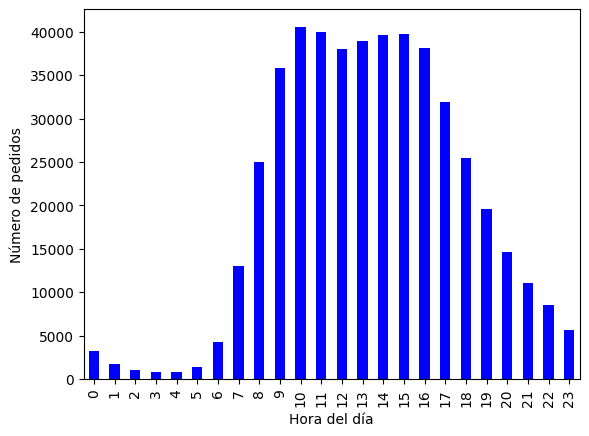

In [36]:
hourly_orders = orders['order_hour_of_day'].value_counts().sort_index()
hourly_orders.plot(kind ='bar', color ='blue')
plt.xlabel('Hora del día')
plt.ylabel('Número de pedidos')

Escribe aquí tus conclusiones
las cosas que saltan a la vista son que apartir de las 9am hasta las 5pm son las horas pico de ordenes

### [A3] ¿Qué día de la semana compran víveres las personas?

([<matplotlib.axis.XTick at 0x7f6518277dc0>,
 [Text(0, 0, 'Dom'),
  Text(1, 0, 'Lun'),
  Text(2, 0, 'Mar'),
  Text(3, 0, 'Mié'),
  Text(4, 0, 'Jue'),
  Text(5, 0, 'Vie'),
  Text(6, 0, 'Sáb')])

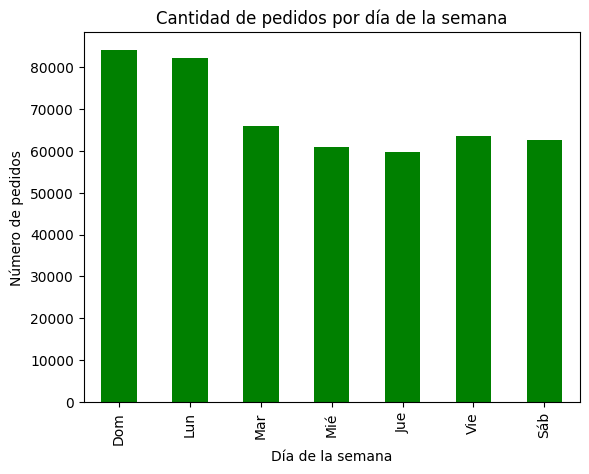

In [37]:
orders_per_day = orders['order_dow'].value_counts().sort_index()
orders_per_day.plot(kind='bar', color='green')
plt.title('Cantidad de pedidos por día de la semana')
plt.xlabel('Día de la semana')
plt.ylabel('Número de pedidos')
plt.xticks(ticks=range(7), labels=['Dom', 'Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb'])

Escribe aquí tus conclusiones
las cosas que saltan a la vista seria que el dia con mayor cantidad de ordenes es el domingo seguido del lunes

### [A4] ¿Cuánto tiempo esperan las personas hasta hacer otro pedido? Comenta sobre los valores mínimos y máximos.

Text(0, 0.5, 'Número de pedidos')

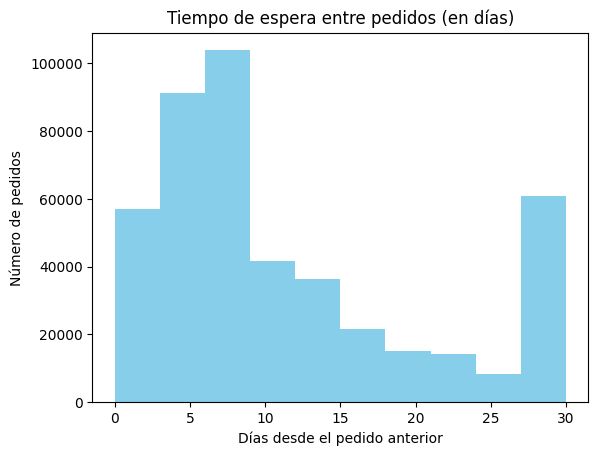

In [38]:
orders['days_since_prior_order'].dropna().plot(kind='hist', color='skyblue')
plt.title('Tiempo de espera entre pedidos (en días)')
plt.xlabel('Días desde el pedido anterior')
plt.ylabel('Número de pedidos')

<div class="alert alert-block alert-success">
<b>Celdas [36–38]</b> <a class="tocSkip"></a><br>
Las visualizaciones para analizar los hábitos de compra por hora del día, día de la semana y tiempo entre pedidos están bien construidas y muestran una buena elección de gráficos. El uso de `hist` para mostrar la distribución de días transcurridos entre compras es particularmente adecuado para este tipo de variable continua. Tus conclusiones también reflejan una buena lectura de los datos.
</div>


Escribe aquí tus conclusiones 
cuando se habla de tiempo creo que el histograma es una mejor forma de representar el grafico
por lo que podemos ver normalmente la mayor frecuencia en los valores minimos estan entre 1 a 10 dias  y los maximos casi los 30 dias es lo que tardan en vovler a pedir

# [B] Intermedio (deben completarse todos para aprobar)

1. ¿Existe alguna diferencia entre las distribuciones `'order_hour_of_day'` de los miércoles y los sábados? Traza gráficos de barra de `'order_hour_of_day'` para ambos días en la misma figura y describe las diferencias que observes.
2. Grafica la distribución para el número de órdenes que hacen los clientes (es decir, cuántos clientes hicieron solo 1 pedido, cuántos hicieron 2, cuántos 3, y así sucesivamente...).
3. ¿Cuáles son los 20 principales productos que se piden con más frecuencia (muestra su identificación y nombre)?

### [B1] Diferencia entre miércoles y sábados para  `'order_hour_of_day'`. Traza gráficos de barra para los dos días y describe las diferencias que veas.

In [39]:
wedn_orders = orders[orders['order_dow'] == 3]
satur_orders = orders[orders['order_dow'] == 6]

In [40]:
wedn_counts = wedn_orders['order_hour_of_day'].value_counts().sort_index()
satur_counts = satur_orders['order_hour_of_day'].value_counts().sort_index()

Text(0, 0.5, 'Cantidad de pedidos')

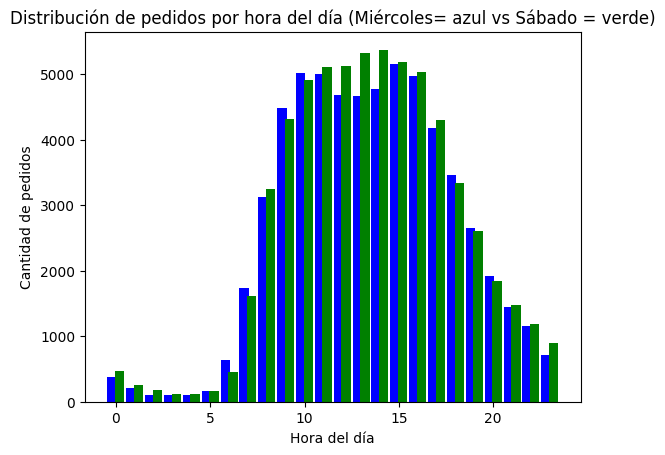

In [41]:
plt.figure()

plt.bar(wedn_counts.index - 0.2, wedn_counts.values, width=0.5, color='blue')
plt.bar(satur_counts.index + 0.2, satur_counts.values, width=0.5, color='green')

plt.title('Distribución de pedidos por hora del día (Miércoles= azul vs Sábado = verde)')
plt.xlabel('Hora del día')
plt.ylabel('Cantidad de pedidos')


Escribe aquí tus conclusiones
los detalles que puedo notar para empezar el miercoles(azul) sus horas pico son 2 momentos en el dia entre 7 am y 11 am  y tiene nuevamente otra hora pico  entre 4 y 5 pm 
mientras que el sabado (verde) tiene muy marcado su horas pico entre 1 y 4 pm

### [B2] ¿Cuál es la distribución para el número de pedidos por cliente?

In [42]:
orders_per_user = orders['user_id'].value_counts()
distribution = orders_per_user.value_counts().sort_index()

Text(0, 0.5, 'Cantidad de clientes')

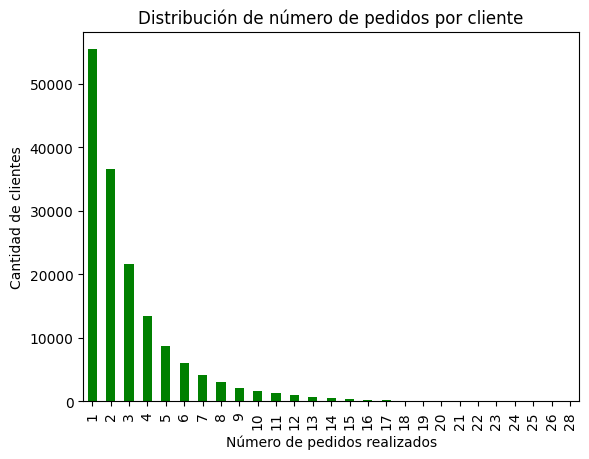

In [43]:
plt.figure()
distribution.plot(kind='bar', color='green')

plt.title('Distribución de número de pedidos por cliente')
plt.xlabel('Número de pedidos realizados')
plt.ylabel('Cantidad de clientes')

Escribe aquí tus conclusiones
la mayoria de clientes suelen hacer un unico pedido eso quiere decir que hay una muy poca retencion de los clientes ya que se pierde casi el 30% de los clientes despues de cada compra es una disminucion constante

### [B3] ¿Cuáles son los 20 productos más populares (muestra su ID y nombre)?

In [44]:
top_products = order_products['product_id'].value_counts().head(20)

In [45]:
top_products_df = top_products.reset_index()
top_products_df.columns = ['product_id', 'order_count']

In [46]:
top_products_named = top_products_df.merge(products[['product_id', 'product_name']], on='product_id')
print(top_products_named)

    product_id  order_count              product_name
0        24852        66050                    BANANA
1        13176        53297    BAG OF ORGANIC BANANAS
2        21137        37039      ORGANIC STRAWBERRIES
3        21903        33971      ORGANIC BABY SPINACH
4        47209        29773      ORGANIC HASS AVOCADO
5        47766        24689           ORGANIC AVOCADO
6        47626        21495               LARGE LEMON
7        16797        20018              STRAWBERRIES
8        26209        19690                     LIMES
9        27845        19600        ORGANIC WHOLE MILK
10       27966        19197       ORGANIC RASPBERRIES
11       22935        15898      ORGANIC YELLOW ONION
12       24964        15292            ORGANIC GARLIC
13       45007        14584          ORGANIC ZUCCHINI
14       39275        13879       ORGANIC BLUEBERRIES
15       49683        13675            CUCUMBER KIRBY
16       28204        12544        ORGANIC FUJI APPLE
17        5876        12232 

Escribe aquí tus conclusiones 
las bananas son nuestro top 1 y 2 de productos mas vendidos lo cual es interesante para tener en cuenta

# [C] Difícil (deben completarse todos para aprobar)

1. ¿Cuántos artículos suelen comprar las personas en un pedido? ¿Cómo es la distribución?
2. ¿Cuáles son los 20 principales artículos que vuelven a pedirse con mayor frecuencia (muestra sus nombres e IDs de los productos)?
3. Para cada producto, ¿cuál es la tasa de repetición del pedido (número de repeticiones de pedido/total de pedidos?
4. Para cada cliente, ¿qué proporción de los productos que pidió ya los había pedido? Calcula la tasa de repetición de pedido para cada usuario en lugar de para cada producto.
5. ¿Cuáles son los 20 principales artículos que la gente pone primero en sus carritos (muestra las IDs de los productos, sus nombres, y el número de veces en que fueron el primer artículo en añadirse al carrito)?

### [C1] ¿Cuántos artículos compran normalmente las personas en un pedido? ¿Cómo es la distribución?

In [47]:
products_per_order = order_products.groupby('order_id')['product_id'].count()

In [48]:
print(products_per_order.mean())

10.098983215049127


In [49]:
print(products_per_order.describe())

count    450046.000000
mean         10.098983
std           7.540206
min           1.000000
25%           5.000000
50%           8.000000
75%          14.000000
max         127.000000
Name: product_id, dtype: float64


Escribe aquí tus conclusiones
en promedio se compran 10 articulos por compra el minimo es 1  y el maximo 127 

### [C2] ¿Cuáles son los 20 principales artículos que vuelven a pedirse con mayor frecuencia (muestra sus nombres e IDs de los productos)?

In [50]:
reorder_products = order_products.groupby('product_id')['reordered'].mean()


In [51]:
top_reordered = reorder_products.sort_values(ascending=False).head(20).reset_index()

In [52]:
top_reordered_named = top_reordered.merge(products[['product_id', 'product_name']], on='product_id')

In [53]:
top_reordered_named

,product_id,reordered,product_name
0,14721,1.0,BONE STRENGTH TAKE CARE
1,20949,1.0,VANILLA SANDWICH COOKIES
2,6723,1.0,PALMIERS- PETITE
3,6732,1.0,NATURALLY SPARKLING MINERAL WATER
4,45088,1.0,CALIFORNIA DILL POLLEN & GARLIC GOAT CHEESE & ...
5,45078,1.0,POMEGRANATEA
6,21016,1.0,PARCHMENT LINED 8 IN X 3.75 IN X 2.5 IN PANS
7,21005,1.0,PEANUT BUTTER PIE ICE CREAM
8,35192,1.0,CHOCOLATE SOY MILK SINGLES
9,35197,1.0,MOCHA CHOCOLATE CHIP ORGANIC NON-DAIRY FROZEN...


<div class="alert alert-block alert-warning">
<b>Celdas [50–53]</b> <a class="tocSkip"></a><br>
Aunque el análisis de los productos con mayor tasa de repetición es correcto a nivel técnico, los resultados podrían estar sesgados por productos con muy pocas observaciones. Todos los productos que aparecen con tasa de repetición del 100% (`reordered == 1.0`) pueden haber sido comprados una sola vez por un único cliente y luego repetidos. Sería útil aplicar un filtro para productos con un mínimo de pedidos (por ejemplo, al menos 50) para obtener conclusiones más robustas.
</div>


Escribe aquí tus conclusiones
analizando los productos muchos de ellos son complementos para comer productos como postres al vender frutas es curioso el observar que con cada compra de cualquier fruta o producto organico se pide algo para complementar el consumo de dichos productos

### [C3] Para cada producto, ¿cuál es la proporción de las veces que se pide y que se vuelve a pedir?

In [54]:
reorder_stats = order_products.groupby('product_id')['reordered'].agg(['sum', 'count'])

In [56]:
reorder_stats['reorder_rate'] = reorder_stats['sum'] / reorder_stats['count']

In [59]:
reorder_stats = reorder_stats.reset_index().merge(products[['product_id', 'product_name']], on='product_id', how='left')

reorder_stats

,product_id,sum,count,reorder_rate,product_name
0,1,158,280,0.564286,CHOCOLATE SANDWICH COOKIES
1,2,0,11,0.000000,ALL-SEASONS SALT
2,3,31,42,0.738095,ROBUST GOLDEN UNSWEETENED OOLONG TEA
3,4,25,49,0.510204,SMART ONES CLASSIC FAVORITES MINI RIGATONI WIT...
4,7,1,2,0.500000,PURE COCONUT WATER WITH ORANGE
...,...,...,...,...,...
45568,49690,4,5,0.800000,HIGH PERFORMANCE ENERGY DRINK
45569,49691,31,72,0.430556,ORIGINAL PANCAKE & WAFFLE MIX
45570,49692,5,12,0.416667,ORGANIC INSTANT OATMEAL LIGHT MAPLE BROWN SUGAR
45571,49693,11,25,0.440000,SPRING WATER BODY WASH


Escribe aquí tus conclusiones
es muy variado pero aproximadamente hablamos de un 50% de probabilidad de que se vuelva a pedir algunos de los productos

### [C4] Para cada cliente, ¿qué proporción de sus productos ya los había pedido?

In [72]:
reorder_per_client = pd.merge(order_products, orders[['order_id', 'user_id']], on='order_id', how='left')
reorder_per_client = reorder_per_client.groupby('user_id')['reordered'].mean()

In [78]:
print(reorder_per_client.head(15))

user_id
2     0.038462
4     0.000000
5     0.666667
6     0.000000
7     0.928571
11    0.200000
12    0.250000
13    0.565217
14    0.360656
15    0.538462
16    0.531250
17    0.716981
19    0.291667
20    0.000000
21    0.400000
Name: reordered, dtype: float64


<div class="alert alert-block alert-success">
<b>Celdas [72–78]</b> <a class="tocSkip"></a><br>
Muy buen uso de `groupby()` para calcular la tasa de repetición por usuario. Este tipo de análisis por cliente aporta una capa adicional muy valiosa al entendimiento de la fidelización en la plataforma. Tus conclusiones, aunque algo generales, reflejan una buena intuición sobre la baja retención de usuarios.
</div>


Escribe aquí tus conclusiones
es demasiado variado como puede ser un 70% puede ser un 3 % de probabilidad de que alguien haga una recompra, como dije anteriormente en mi analisis hay una decaida de almenos el 30% en la fidelidad de los clientes y no suelen continuar por mucho tiempo haciendo recompras

### [C5] ¿Cuáles son los 20 principales artículos que las personas ponen primero en sus carritos?

In [80]:
added_products = order_products[order_products['add_to_cart_order'] == 1]
top_added_products = added_products['product_id'].value_counts().head(20)

In [81]:
top_added_names = pd.merge(top_added_products, products[['product_id', 'product_name']], on='product_id', how='left')

In [82]:
print(top_added_names)

    product_id                                       product_name
0        15562             VITAMIN CODE RAW D3 VITAMIN SUPPLEMENT
1        11026                                            Unknwon
2         4363                                    AMBROSIA APPLES
3         3946        HOMEMADE ICE CREAM BALLS CHOCOLATE ESPRESSO
4         3390                                             PAPAYA
5         3336    FRUIT & ALMOND BUTTER BLUEBERRY CINNAMON WALNUT
6         3044            ORIGINAL 100% PURE NO PULP ORANGE JUICE
7         2336   PASTA SIDES- PARMESAN FETTUCCINI & SPINACH PASTA
8         2308                                     BUBBLEMINT GUM
9         2024  ORGANIC DICED TOMATOES FIRE ROASTED WITH MEDIU...
10        1914   ORIGINAL HABANERO PEPPER SAUCE- XXXTRA HOT SAUCE
11        1797                           ANTIBACTERIAL SOAP BEIGE
12        1737                         POPCORN SHRIMP OVEN CRISPY
13        1733                               MILD PINEAPPLE SALSA
14        

Escribe aquí tus conclusiones
no logro observar una tendencia en las compras son muy erraticas 

### Conclusion general del proyecto:

comentarios al proyecto al inicio parecia mas una tienda de productos organicos y que tiene un grave problema de retencion de cliente o fidelizacion de los mismos. el dato de mayor importancia que note es la caida de los clientes al hacer recompras me hace pensar que sus productos no son tan buenos o tiene un mal manejo de los mismos.

<div class="alert alert-block alert-success">
<b>Comentario final</b> <a class="tocSkip"></a><br>
¡Felicidades, Aron! Tu proyecto refleja un dominio sólido del flujo de trabajo en ciencia de datos: cargaste, limpiaste y analizaste los datos con lógica clara y visualizaciones adecuadas. Identificaste correctamente valores ausentes, duplicados y realizaste análisis que permiten entender patrones clave de comportamiento.¡Vas por excelente camino!
</div>
